In [ ]:
#  Core Libraries
!pip install -q numpy pandas matplotlib tqdm

#  Audio Processing
!pip install -q librosa soundfile

#  Machine Learning + DL
!pip install -q tensorflow scikit-learn keras-tuner


# TODO: 
    - Add gradient accumulation for larger effective batch sizes if needed.

In [11]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from tqdm import tqdm

# === Global Config ===
SEED = 42
np.random.seed(SEED)

# === Audio Constants ===
SR = 22050                # Sample rate
N_MELS = 256              # Mel bands
FMAX = 8000               # Max frequency for mel filter
FIXED_TIME_STEPS = 150    # Output width for spectrogram

# === Path Config ===

# Detect if running on Kaggle or locally
def detect_env():
    if os.path.exists("/kaggle/input"):
        return "kaggle"
    else:
        return "local"

ENV = detect_env()

# Base directory (relative to notebook/project root)
BASE_DIR = os.path.abspath(".")

# Dataset folder — your central data folder
DATASET_DIR = os.path.join(BASE_DIR, "dataset")

# Paths inside dataset
AUDIO_DIR = os.path.join(DATASET_DIR, "Train")
CSV_PATH = os.path.join(DATASET_DIR, "Train.csv")
CACHE_DIR = os.path.join(DATASET_DIR, "mel_cache")  

# Ensure required folders exist
os.makedirs(CACHE_DIR, exist_ok=True)

# === Load CSV Metadata ===
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f" CSV file not found at: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)
df["filepath"] = df["file_name"].apply(lambda x: os.path.join(AUDIO_DIR, x))

# Optional debug info
print(f" Loaded metadata: {len(df)} files found")
print(f" Example audio path: {df['filepath'].iloc[0]}")
print(f" Mel cache path: {CACHE_DIR}")

df = pd.read_csv(CSV_PATH)
df["filepath"] = df["file_name"].apply(lambda x: os.path.join(AUDIO_DIR, x))
df.head()

 Loaded metadata: 7057 files found
 Example audio path: d:\TBA\deep_learning_project\dataset\Train\data_0.wav
 Mel cache path: d:\TBA\deep_learning_project\dataset\mel_cache


,file_name,classID,filepath
0,data_0.wav,3,d:\TBA\deep_learning_project\dataset\Train\dat...
1,data_1.wav,3,d:\TBA\deep_learning_project\dataset\Train\dat...
2,data_2.wav,3,d:\TBA\deep_learning_project\dataset\Train\dat...
3,data_3.wav,3,d:\TBA\deep_learning_project\dataset\Train\dat...
4,data_4.wav,6,d:\TBA\deep_learning_project\dataset\Train\dat...


In [12]:
def mel_cache_audio(df, filepath_col="filepath", add_to_df=True):
    created, skipped, failed = 0, 0, 0
    mel_paths = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="🔉 Caching mel spectrograms"):
        wav_path = row[filepath_col]
        out_path = os.path.join(CACHE_DIR, os.path.basename(wav_path).replace(".wav", "_mel.npy"))
        mel_paths.append(out_path)

        if os.path.exists(out_path):
            skipped += 1
            continue

        if not os.path.exists(wav_path):
            tqdm.write(f" Missing file: {wav_path}")
            failed += 1
            continue

        try:
            y, sr = librosa.load(wav_path, sr=SR)
            if sr != SR:
                tqdm.write(f" Sample rate mismatch: {wav_path} (got {sr}, expected {SR})")

            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, fmax=FMAX)
            mel_db = librosa.power_to_db(mel, ref=np.max)
            mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
            mel_db = librosa.util.fix_length(mel_db, size=FIXED_TIME_STEPS, axis=1)
            mel_db = np.expand_dims(mel_db, axis=-1)

            np.save(out_path, mel_db)
            created += 1

        except Exception as e:
            tqdm.write(f" Error processing {wav_path}: {e}")
            failed += 1

    tqdm.write(f"\n Mel caching complete → Created: {created}, Skipped: {skipped}, Failed: {failed}")

    if add_to_df:
        df["mel_path"] = mel_paths

    return df if add_to_df else None


In [13]:
df = mel_cache_audio(df)
print(df.head())

🔉 Caching mel spectrograms:  12%|█▏        | 831/7057 [00:31<02:55, 35.46it/s] c:\Users\emink\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
c:\Users\emink\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
🔉 Caching mel spectrograms:  12%|█▏        | 836/7057 [00:31<02:45, 37.54it/s]c:\Users\emink\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
🔉 Caching mel spectrograms: 100%|██████████| 7057/7057 [03:43<00:00, 31.58it/s]


 Mel caching complete → Created: 7057, Skipped: 0, Failed: 0
    file_name  classID                                           filepath  \
0  data_0.wav        3  d:\TBA\deep_learning_project\dataset\Train\dat...   
1  data_1.wav        3  d:\TBA\deep_learning_project\dataset\Train\dat...   
2  data_2.wav        3  d:\TBA\deep_learning_project\dataset\Train\dat...   
3  data_3.wav        3  d:\TBA\deep_learning_project\dataset\Train\dat...   
4  data_4.wav        6  d:\TBA\deep_learning_project\dataset\Train\dat...   

                                            mel_path  
0  d:\TBA\deep_learning_project\dataset\mel_cache...  
1  d:\TBA\deep_learning_project\dataset\mel_cache...  
2  d:\TBA\deep_learning_project\dataset\mel_cache...  
3  d:\TBA\deep_learning_project\dataset\mel_cache...  
4  d:\TBA\deep_learning_project\dataset\mel_cache...  


In [14]:
def inspect_cached_mels(df, n=5):
    """
    Randomly inspects N cached mel spectrograms from the DataFrame.

    - Prints shape, min/max, and sparsity.
    - Checks file existence.
    - Falls back to generating path if 'mel_path' column is missing.
    """
    print(f"\n Inspecting {n} random cached mel spectrograms...")
    sample_files = df.sample(n, random_state=np.random.randint(9999))

    for _, row in sample_files.iterrows():
        mel_path = row.get("mel_path")

        # Fallback if mel_path is not in the DataFrame
        if not mel_path or not os.path.exists(mel_path):
            mel_path = os.path.join(
                CACHE_DIR,
                os.path.basename(row["filepath"]).replace(".wav", "_mel.npy")
            )

        if not os.path.exists(mel_path):
            print(f" Missing file: {mel_path}")
            continue

        try:
            mel = np.load(mel_path)
            print(f" {os.path.basename(mel_path)}")
            print(f"  - Shape     : {mel.shape}")
            print(f"  - Min/Max   : {mel.min():.3f} / {mel.max():.3f}")
            print(f"  - Nonzero % : {np.count_nonzero(mel) / mel.size * 100:.2f}%")
        except Exception as e:
            print(f" Failed to load {mel_path}: {e}")


In [15]:
inspect_cached_mels(df, n=5)


 Inspecting 5 random cached mel spectrograms...
 data_4218_mel.npy
  - Shape     : (256, 150, 1)
  - Min/Max   : 0.000 / 1.000
  - Nonzero % : 100.00%
 data_2661_mel.npy
  - Shape     : (256, 150, 1)
  - Min/Max   : 0.000 / 1.000
  - Nonzero % : 100.00%
 data_318_mel.npy
  - Shape     : (256, 150, 1)
  - Min/Max   : 0.000 / 1.000
  - Nonzero % : 100.00%
 data_6731_mel.npy
  - Shape     : (256, 150, 1)
  - Min/Max   : 0.000 / 1.000
  - Nonzero % : 100.00%
 data_5493_mel.npy
  - Shape     : (256, 150, 1)
  - Min/Max   : 0.000 / 1.000
  - Nonzero % : 100.00%


In [25]:
import torch
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader
import random
from functools import partial


def torch_augment_mel(mel):
    """
    Apply data augmentation to mel spectrogram.
    Expects `mel` of shape (1, H, W) and type torch.Tensor.
    """
    B, H, W = mel.shape[-3], mel.shape[-2], mel.shape[-1]

    # Time stretch (simulate by rescaling width)
    if torch.rand(1).item() < 0.5:
        stretch_factor = torch.empty(1).uniform_(0.8, 1.2).item()
        new_width = int(W * stretch_factor)
        mel = F.interpolate(mel.unsqueeze(0), size=(H, new_width), mode='bilinear', align_corners=False).squeeze(0)
        mel = F.interpolate(mel.unsqueeze(0), size=(H, W), mode='bilinear', align_corners=False).squeeze(0)

    # Time mask
    if torch.rand(1).item() < 0.7:
        mask_t = int(0.15 * W)
        t0 = torch.randint(0, W - mask_t, (1,)).item()
        mel[:, :, t0:t0+mask_t] = 0

    # Frequency mask
    if torch.rand(1).item() < 0.7:
        mask_f = int(0.15 * H)
        f0 = torch.randint(0, H - mask_f, (1,)).item()
        mel[:, f0:f0+mask_f, :] = 0

    # Gaussian noise
    if torch.rand(1).item() < 0.5:
        noise = torch.randn_like(mel) * 0.01
        mel = mel + noise

    # Frequency shift
    if torch.rand(1).item() < 0.5:
        shift = torch.randint(-4, 5, (1,)).item()
        mel = torch.roll(mel, shifts=shift, dims=1)

    # Volume jitter
    if torch.rand(1).item() < 0.8:
        scale = torch.empty(1).uniform_(0.8, 1.2).item()
        mel = mel * scale

    # Soft clipping
    if torch.rand(1).item() < 0.3:
        mel = torch.tanh(mel)
        mel = (mel + 1.0) / 2.0

    # Normalize to [0, 1]
    mel_min = mel.min()
    mel_max = mel.max()
    mel = (mel - mel_min) / (mel_max - mel_min + 1e-6)

    return mel


def mixup_batch(images, labels, num_classes, alpha=0.4):
    """
    PyTorch version of Mixup augmentation.
    - images: (B, C, H, W)
    - labels: (B,) as integers
    - Returns: (mixed_images, mixed_labels) with soft one-hot labels
    """
    batch_size = images.size(0)

    # Sample λ from Beta distribution
    lam = torch.distributions.Beta(alpha, alpha).sample((batch_size,)).to(images.device)
    lam = torch.maximum(lam, 1 - lam)  # enforce λ ≥ 0.5

    # Create shuffled indices
    index = torch.randperm(batch_size).to(images.device)

    # One-hot encode labels
    labels_onehot = F.one_hot(labels, num_classes=num_classes).float()
    labels_shuffled = labels_onehot[index]

    # Reshape λ for broadcasting
    lam_x = lam.view(-1, 1, 1, 1)
    lam_y = lam.view(-1, 1)

    mixed_images = images * lam_x + images[index] * (1 - lam_x)
    mixed_labels = labels_onehot * lam_y + labels_shuffled * (1 - lam_y)

    return mixed_images, mixed_labels



def cutmix_batch(images, labels, num_classes, alpha=1.0):
    """
    CutMix for PyTorch.
    
    Args:
        images: Tensor of shape (B, C, H, W)
        labels: Tensor of shape (B,) — integer class labels
        num_classes: Number of classes
        alpha: Beta distribution parameter for lambda
    
    Returns:
        mixed_images: (B, C, H, W)
        mixed_labels: (B, num_classes) — soft one-hot labels
    """
    B, C, H, W = images.shape

    # Sample lambda from Beta distribution
    lam = torch.distributions.Beta(alpha, alpha).sample((B,)).to(images.device)
    lam = torch.maximum(lam, 1 - lam)  # enforce λ ≥ 0.5

    # Random positions for cut box
    cut_rat = torch.sqrt(1.0 - lam)
    cut_w = (W * cut_rat).int()
    cut_h = (H * cut_rat).int()
    cx = torch.randint(0, W, (B,), device=images.device)
    cy = torch.randint(0, H, (B,), device=images.device)

    # Shuffle the batch
    indices = torch.randperm(B).to(images.device)
    shuffled_images = images[indices]
    shuffled_labels = labels[indices]

    # One-hot encode
    labels_onehot = F.one_hot(labels, num_classes).float()
    shuffled_onehot = F.one_hot(shuffled_labels, num_classes).float()

    mixed_images = images.clone()
    mixed_labels = torch.zeros_like(labels_onehot)

    for i in range(B):
        x1 = torch.clamp(cx[i] - cut_w[i] // 2, 0, W)
        x2 = torch.clamp(cx[i] + cut_w[i] // 2, 0, W)
        y1 = torch.clamp(cy[i] - cut_h[i] // 2, 0, H)
        y2 = torch.clamp(cy[i] + cut_h[i] // 2, 0, H)

        # Apply cut
        mixed_images[i, :, y1:y2, x1:x2] = shuffled_images[i, :, y1:y2, x1:x2]

        # Area and label mix
        box_area = (x2 - x1) * (y2 - y1)
        lam_i = 1.0 - box_area.float() / (H * W)
        mixed_labels[i] = labels_onehot[i] * lam_i + shuffled_onehot[i] * (1 - lam_i)

    return mixed_images, mixed_labels



class MelSpectrogramDataset(Dataset):
    def __init__(self, file_paths, labels, augment=False,
                 return_onehot_labels=False, num_classes=10):
        self.file_paths = file_paths
        self.labels = labels
        self.augment = augment
        self.return_onehot = return_onehot_labels
        self.num_classes = num_classes

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        mel = np.load(self.file_paths[idx])
        mel = torch.tensor(mel, dtype=torch.float32).permute(2, 0, 1)  # (1, H, W)
        label = self.labels[idx]

        if self.augment:
            mel = torch_augment_mel(mel)

        if self.return_onehot:
            label = torch.nn.functional.one_hot(torch.tensor(label), num_classes=self.num_classes).float()
        else:
            label = torch.tensor(label, dtype=torch.long)

        return mel, label


def collate_with_mix(batch, mix_strategy="none", num_classes=10, mix_prob=0.5):
    images, labels = zip(*batch)
    images = torch.stack(images)
    labels = torch.stack(labels)

    if mix_strategy == "mixup":
        return mixup_batch(images, labels, num_classes)
    elif mix_strategy == "cutmix":
        return cutmix_batch(images, labels, num_classes)
    elif mix_strategy in ["both", "random"]:
        if random.random() < mix_prob:
            return mixup_batch(images, labels, num_classes)
        else:
            return cutmix_batch(images, labels, num_classes)
    else:
        return images, labels


def create_mel_dataloader(file_paths, labels,
                          batch_size=32,
                          shuffle=True,
                          augment=False,
                          mix_strategy="none",
                          mix_prob=0.5,
                          num_classes=10,
                          return_onehot_labels=False,
                          num_workers=0):
    """
    Creates a PyTorch DataLoader with optional augment + mix strategies.
    """
    dataset = MelSpectrogramDataset(
        file_paths=file_paths,
        labels=labels,
        augment=augment,
        return_onehot_labels=return_onehot_labels,
        num_classes=num_classes
    )

    collate_fn = partial(collate_with_mix, mix_strategy=mix_strategy, num_classes=num_classes, mix_prob=mix_prob)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        collate_fn=collate_fn,
        pin_memory=True
    )

    return loader



# Validating Augmentation-Mixup-CutMix-Data Loader

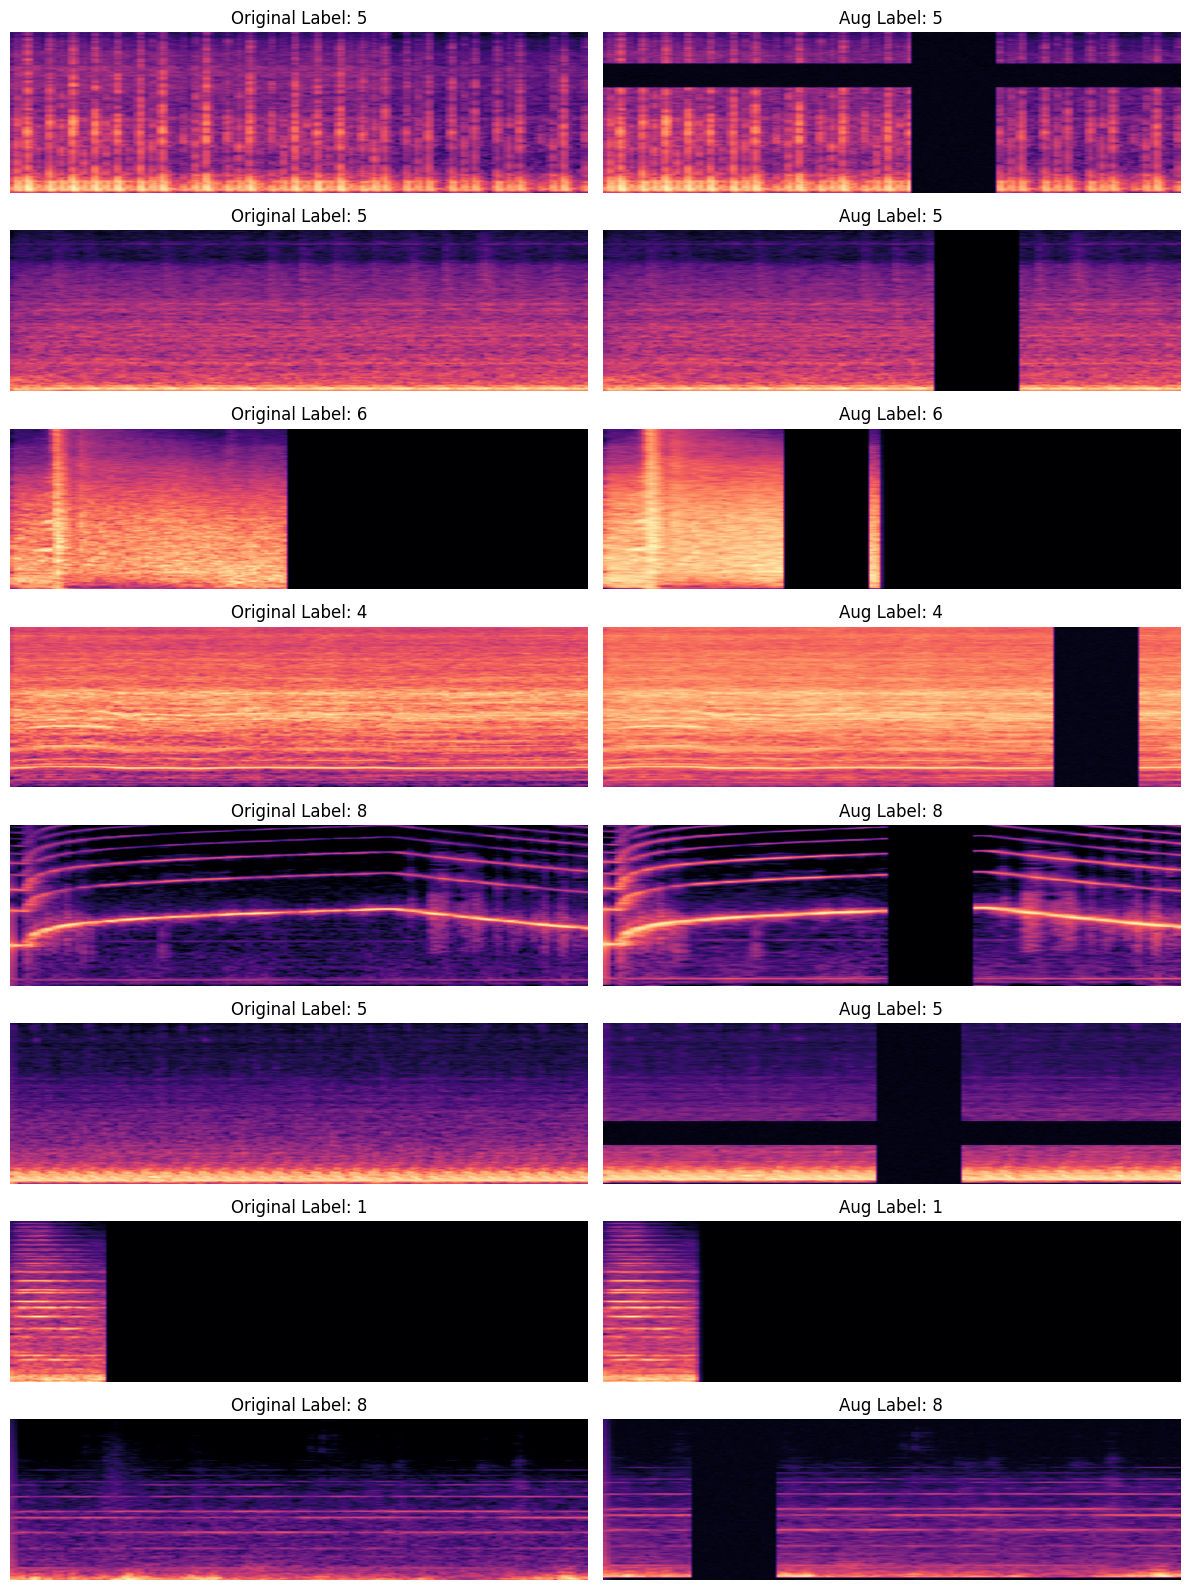

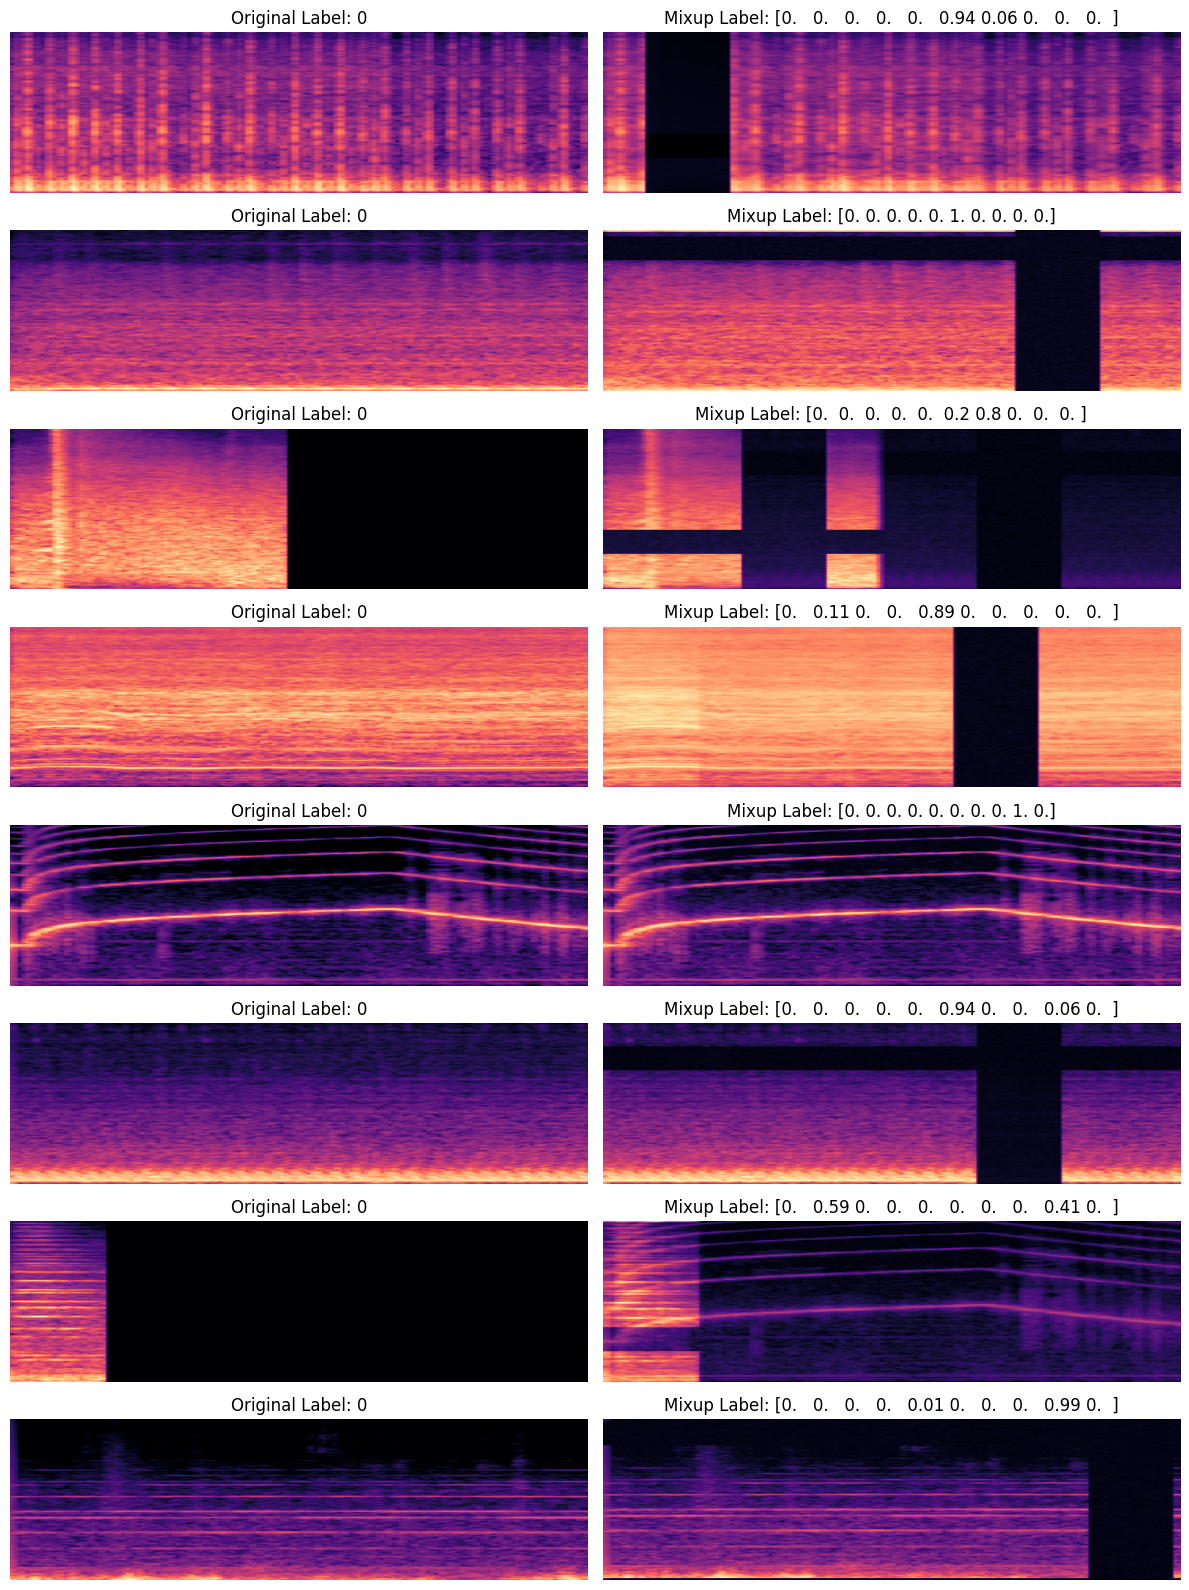

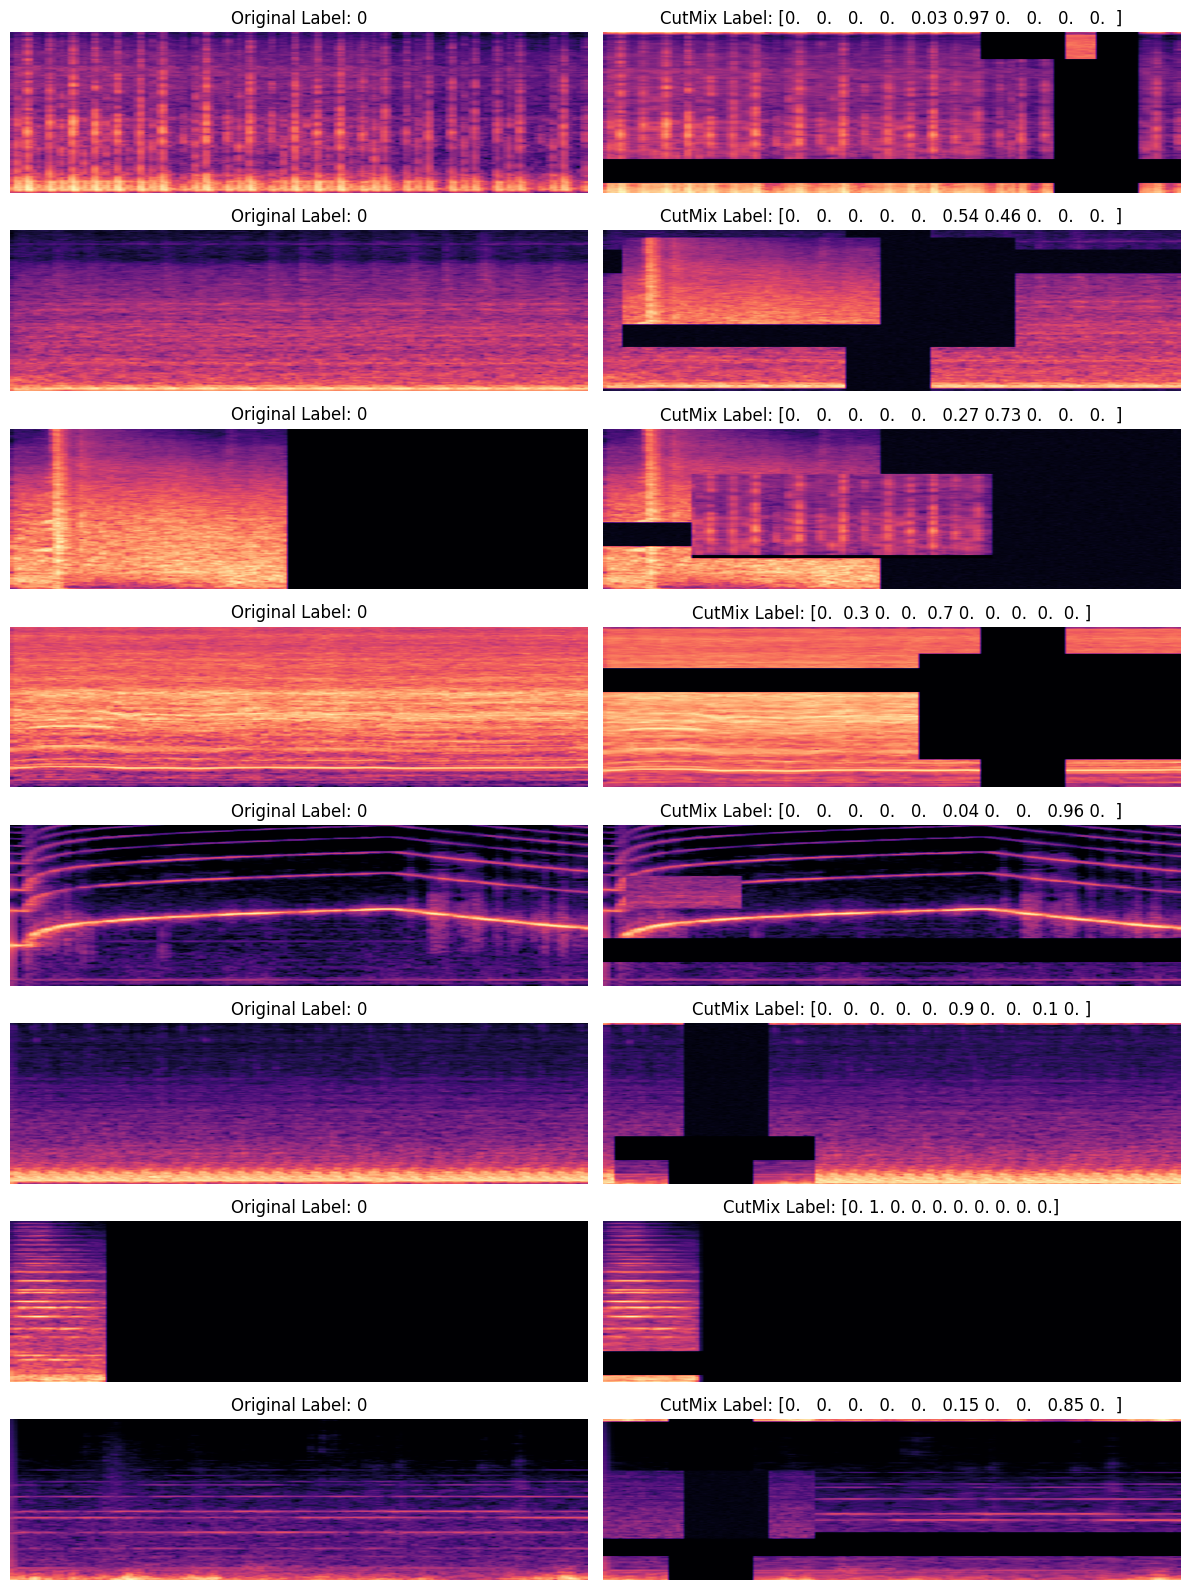

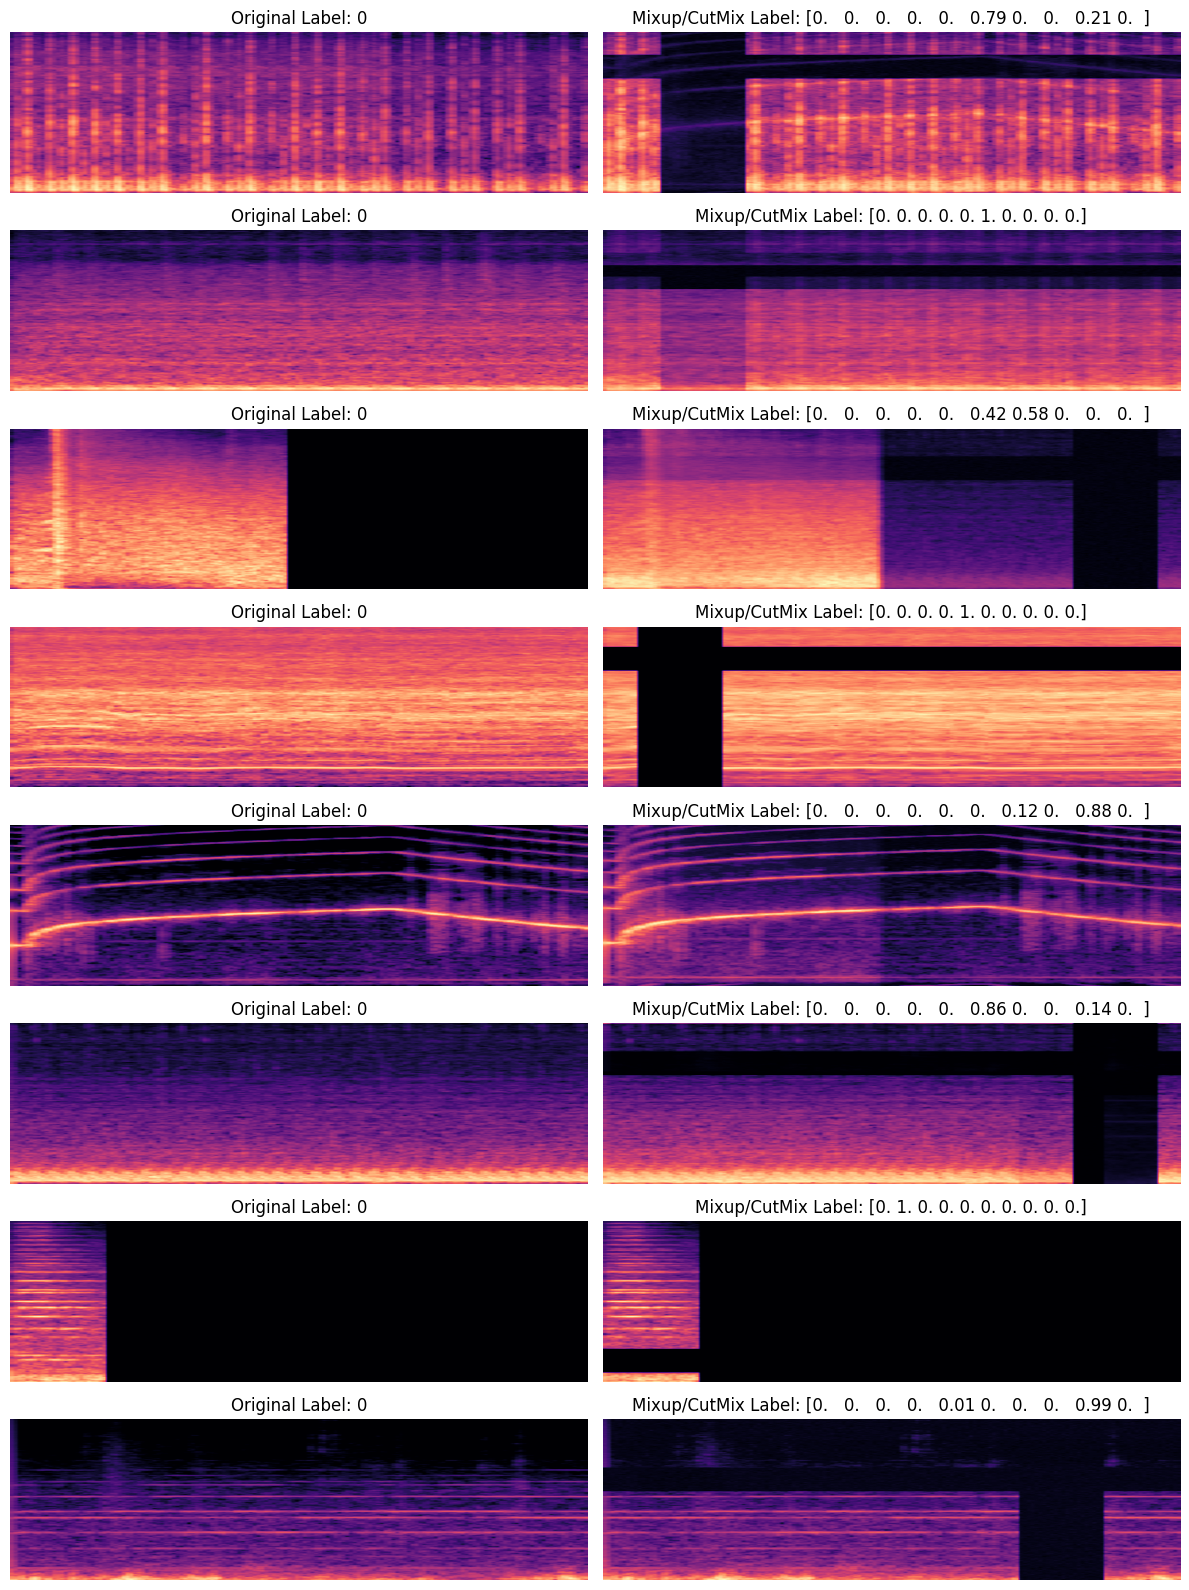

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

# === Sample real data from df ===
sample_df = df.sample(8, random_state=np.random.randint(99999))
sample_paths = sample_df["mel_path"].values
sample_labels = sample_df["classID"].values

# === Create dataloaders ===
dl_plain = create_mel_dataloader(sample_paths, sample_labels, batch_size=8, augment=False, mix_strategy="none", shuffle=False)
dl_aug   = create_mel_dataloader(sample_paths, sample_labels, batch_size=8, augment=True,  mix_strategy="none", shuffle=False)
dl_mix   = create_mel_dataloader(sample_paths, sample_labels, batch_size=8, augment=True,  mix_strategy="mixup", shuffle=False)
dl_cut   = create_mel_dataloader(sample_paths, sample_labels, batch_size=8, augment=True,  mix_strategy="cutmix", shuffle=False)
dl_both  = create_mel_dataloader(sample_paths, sample_labels, batch_size=8, augment=True,  mix_strategy="both",  shuffle=False)

# === Visualization Function ===
def visualize_pairwise(original_dl, aug_dl, is_soft=False, title_prefix="Aug"):
    mels_orig, labels_orig = next(iter(original_dl))
    mels_aug,  labels_aug  = next(iter(aug_dl))

    plt.figure(figsize=(12, 16))
    for i in range(len(mels_orig)):
        # Original
        plt.subplot(len(mels_orig), 2, 2 * i + 1)
        plt.imshow(mels_orig[i].squeeze().numpy(), aspect="auto", origin="lower", cmap="magma")
        label_display = f"{torch.argmax(labels_orig[i]).item()}" if is_soft else f"{int(labels_orig[i])}"
        plt.title(f"Original Label: {label_display}")
        plt.axis("off")

        # Augmented / Mixup / CutMix
        plt.subplot(len(mels_orig), 2, 2 * i + 2)
        plt.imshow(mels_aug[i].squeeze().numpy(), aspect="auto", origin="lower", cmap="magma")
        if is_soft:
            label_display = np.round(labels_aug[i].numpy(), 2)
        else:
            label_display = f"{int(labels_aug[i])}"
        plt.title(f"{title_prefix} Label: {label_display}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# === Show all variants ===
try:
    visualize_pairwise(dl_plain, dl_aug, is_soft=False, title_prefix="Aug")
except Exception as e:
    print(f"[Error] Aug visualization failed: {e}")

try:
    visualize_pairwise(dl_plain, dl_mix, is_soft=True, title_prefix="Mixup")
except Exception as e:
    print(f"[Error] Mixup visualization failed: {e}")

try:
    visualize_pairwise(dl_plain, dl_cut, is_soft=True, title_prefix="CutMix")
except Exception as e:
    print(f"[Error] CutMix visualization failed: {e}")

try:
    visualize_pairwise(dl_plain, dl_both, is_soft=True, title_prefix="Mixup/CutMix")
except Exception as e:
    print(f"[Error] Mixup/CutMix visualization failed: {e}")


# Model Architecture

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# === Attention Block ===
class AttentionBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.channel_attn = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, in_channels // 8, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(in_channels // 8, in_channels, kernel_size=1),
            nn.Sigmoid()
        )
        self.spatial_attn = nn.Conv2d(in_channels, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        ch_attn = self.channel_attn(x)
        x = x * ch_attn

        sp_attn = self.sigmoid(self.spatial_attn(x))
        x = x * sp_attn

        return x

# === Residual Block with SE ===
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, l2_val=0.0, use_se=False, activation="relu", norm_type="batch"):
        super().__init__()
        norm = nn.BatchNorm2d if norm_type == "batch" else nn.LayerNorm
        act = {"relu": nn.ReLU, "swish": nn.SiLU, "gelu": nn.GELU}[activation]

        self.use_se = use_se
        self.same_channels = (in_channels == out_channels)

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm1 = norm(out_channels)
        self.act1 = act()

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = norm(out_channels)

        if not self.same_channels:
            self.proj = nn.Conv2d(in_channels, out_channels, kernel_size=1)
            self.proj_norm = norm(out_channels)

        if use_se:
            self.se = nn.Sequential(
                nn.AdaptiveAvgPool2d(1),
                nn.Conv2d(out_channels, out_channels // 8, 1),
                nn.ReLU(),
                nn.Conv2d(out_channels // 8, out_channels, 1),
                nn.Sigmoid()
            )

        self.final_act = act()

    def forward(self, x):
        shortcut = x
        x = self.act1(self.norm1(self.conv1(x)))
        x = self.norm2(self.conv2(x))

        if self.use_se:
            x = x * self.se(x)

        if not self.same_channels:
            shortcut = self.proj_norm(self.proj(shortcut))

        return self.final_act(x + shortcut)

# === Full Model ===
class MelSpectrogramClassifier(nn.Module):
    def __init__(self, config, num_classes=10):
        super().__init__()
        self.mix = config.get("use_mix", False)

        act_type = config.get("activation", "relu")
        norm_type = config.get("norm_type", "batch")
        pool_type = config.get("pool_type", "max")

        act = {"relu": nn.ReLU, "swish": nn.SiLU, "gelu": nn.GELU}[act_type]
        norm = nn.BatchNorm2d if norm_type == "batch" else nn.LayerNorm

        filters = config.get("filters_start", 48)
        depth = config.get("depth", 2)
        dropout = config.get("dropout", 0.4)
        dense_units = config.get("dense_units", 128)
        num_dense = config.get("num_dense", 1)
        use_attention = config.get("use_attention", False)
        use_residual = config.get("use_residual", False)
        use_se_attention = config.get("use_se_attention", False)

        layers = []
        in_channels = 1

        for _ in range(depth):
            if use_residual:
                layers.append(ResidualBlock(in_channels, filters, use_se=use_se_attention,
                                            activation=act_type, norm_type=norm_type))
            else:
                layers += [
                    nn.Conv2d(in_channels, filters, kernel_size=3, padding=1),
                    norm(filters),
                    act(),
                    nn.Conv2d(filters, filters, kernel_size=3, padding=1),
                    norm(filters),
                    act()
                ]

            if pool_type == "max":
                layers.append(nn.MaxPool2d(2))
            else:
                layers.append(nn.AvgPool2d(2))

            in_channels = filters
            filters *= 2

        if use_attention and not use_residual:
            layers.append(AttentionBlock(in_channels))

        self.feature_extractor = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d(1)

        fc_layers = []
        in_features = in_channels
        for _ in range(num_dense):
            fc_layers.append(nn.Linear(in_features, dense_units))
            fc_layers.append(nn.Dropout(dropout))
            fc_layers.append(act())
            in_features = dense_units

        self.classifier = nn.Sequential(*fc_layers)
        self.output_layer = nn.Linear(in_features, num_classes)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.pool(x).squeeze(-1).squeeze(-1)
        x = self.classifier(x)
        x = self.output_layer(x)
        return F.log_softmax(x, dim=1) if self.mix else x


# Hyperparameter Tuner - hyperband

In [ ]:
import optuna
import torch
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from torch.nn.functional import cross_entropy, kl_div
from torch.optim.lr_scheduler import CosineAnnealingLR, ExponentialLR

def run_optuna_tuning(file_paths, labels,
                      max_epochs=20,
                      timeout_seconds=60 * 60 * 9,
                      project_name="optuna_tune",
                      num_classes=10,
                      device="cuda" if torch.cuda.is_available() else "cpu"):
    """
    Runs Optuna hyperparameter tuning with dynamic mix strategy, batch size, timeout, and persistence.
    Results are stored in `optuna_tune.db` for resume support.
    """

    if len(file_paths) == 0 or len(labels) == 0:
        raise ValueError("file_paths or labels are empty.")
    if len(np.unique(labels)) < 2:
        raise ValueError("Need at least 2 classes.")
    
    print(f" Using device: {device}")

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, val_idx = next(sss.split(file_paths, labels))
    x_train, y_train = file_paths[train_idx], labels[train_idx]
    x_val, y_val = file_paths[val_idx], labels[val_idx]

    weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

    def objective(trial):
        config = {
            "dropout": trial.suggest_float("dropout", 0.3, 0.6, step=0.1),
            "l2": trial.suggest_float("l2", 1e-5, 1e-3, log=True),
            "filters_start": trial.suggest_categorical("filters_start", [32, 48, 64]),
            "depth": trial.suggest_int("depth", 2, 4),
            "dense_units": trial.suggest_categorical("dense_units", [64, 128, 256]),
            "num_dense": trial.suggest_int("num_dense", 1, 2),
            "use_attention": trial.suggest_categorical("use_attention", [True, False]),
            "use_residual": trial.suggest_categorical("use_residual", [True, False]),
            "use_se_attention": trial.suggest_categorical("use_se_attention", [True, False]),
            "pool_type": trial.suggest_categorical("pool_type", ["max", "avg"]),
            "activation": trial.suggest_categorical("activation", ["relu", "swish", "gelu"]),
            "norm_type": trial.suggest_categorical("norm_type", ["batch", "layer"]),
            "lr_schedule": trial.suggest_categorical("lr_schedule", ["none", "cosine", "plateau"]),
            "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-3, log=True),

            # Newly added for tuning
            "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64]),
            "mix_strategy": trial.suggest_categorical("mix_strategy", ["none", "mixup", "cutmix", "both"]),
            "mix_prob": trial.suggest_float("mix_prob", 0.3, 0.7, step=0.1),
        }

        config["use_mix"] = config["mix_strategy"] != "none"

        train_loader = create_mel_dataloader(
            x_train, y_train,
            batch_size=config["batch_size"],
            augment=True,
            mix_strategy=config["mix_strategy"],
            mix_prob=config["mix_prob"],
            num_classes=num_classes,
            return_onehot_labels=config["use_mix"],
            shuffle=True
        )

        val_loader = create_mel_dataloader(
            x_val, y_val,
            batch_size=config["batch_size"],
            augment=False,
            mix_strategy="none",
            return_onehot_labels=config["use_mix"],
            num_classes=num_classes,
            shuffle=False
        )

        model = MelSpectrogramClassifier(config=config, num_classes=num_classes).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])

        if config["lr_schedule"] == "cosine":
            scheduler = CosineAnnealingLR(optimizer, T_max=max_epochs)
        elif config["lr_schedule"] == "plateau":
            scheduler = ExponentialLR(optimizer, gamma=0.9)
        else:
            scheduler = None

        best_val_acc = 0.0

        for epoch in range(max_epochs):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                preds = model(xb)
                if config["use_mix"]:
                    loss = kl_div(preds, yb, reduction='batchmean', log_target=False)
                else:
                    loss = cross_entropy(preds, yb, weight=class_weights)
                loss.backward()
                optimizer.step()
            if scheduler:
                scheduler.step()

            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    preds = model(xb)
                    preds = torch.argmax(preds, dim=1)
                    if config["use_mix"]:
                        yb = torch.argmax(yb, dim=1)
                    correct += (preds == yb).sum().item()
                    total += yb.size(0)

            val_acc = correct / total
            best_val_acc = max(best_val_acc, val_acc)

        return best_val_acc

    #  Persistent + Resumable Study
    study = optuna.create_study(
        direction="maximize",
        study_name=project_name,
        storage=f"sqlite:///{project_name}.db",
        load_if_exists=True
    )

    study.optimize(objective, timeout=timeout_seconds, show_progress_bar=True)

    print("\n Best Trial:")
    for key, val in study.best_trial.params.items():
        print(f"  {key}: {val}")

    return study.best_trial


# Training 

In [40]:
import os
import json
import torch
import numpy as np
from datetime import datetime
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from torch.nn.functional import cross_entropy, kl_div
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

def train_kfold_pytorch(file_paths, labels, best_hp,
                        n_splits=5,
                        epochs=50,
                        model_dir="models",
                        tensorboard_mode="off",  # "off", "local"
                        device="cuda" if torch.cuda.is_available() else "cpu"):
    """
    Trains model using Stratified K-Fold. Logs checkpoints, CSV logs, and TensorBoard logs.

    Returns:
        List of fold metrics with best accuracy, loss, paths.
    """

    if best_hp is None:
        raise ValueError("Please provide best_hp from tuning.")

    os.makedirs(model_dir, exist_ok=True)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(file_paths, labels)):
        fold_name = f"fold_{fold + 1}"
        model_path = os.path.join(model_dir, f"{fold_name}_best_model.pt")
        log_dir = os.path.join("logs", f"{fold_name}_{datetime.now().strftime('%Y%m%d-%H%M%S')}")
        os.makedirs(log_dir, exist_ok=True)

        print(f"\n Starting {fold_name}...")

        if os.path.exists(model_path):
            print(f"Model already exists at {model_path}. Skipping.")
            fold_metrics.append({
                "fold": fold + 1,
                "val_accuracy": None,
                "val_loss": None,
                "model_path": model_path,
                "log_dir": log_dir,
                "history": None
            })
            continue

        # === Data Prep ===
        x_train, y_train = file_paths[train_idx], labels[train_idx]
        x_val, y_val = file_paths[val_idx], labels[val_idx]

        batch_size = best_hp["batch_size"]
        mix_strategy = best_hp["mix_strategy"]
        mix_prob = best_hp["mix_prob"]
        use_mix = mix_strategy != "none"

        class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
        class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

        train_loader = create_mel_dataloader(
            x_train, y_train, batch_size=batch_size,
            augment=True, mix_strategy=mix_strategy,
            mix_prob=mix_prob, return_onehot_labels=use_mix
        )
        val_loader = create_mel_dataloader(
            x_val, y_val, batch_size=batch_size,
            augment=False, mix_strategy="none",
            return_onehot_labels=use_mix
        )

        model = MelSpectrogramClassifier(config=best_hp, num_classes=10).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=best_hp["learning_rate"])

        # Optional scheduler
        if best_hp["lr_schedule"] == "cosine":
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
        elif best_hp["lr_schedule"] == "plateau":
            scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
        else:
            scheduler = None

        writer = SummaryWriter(log_dir) if tensorboard_mode != "off" else None
        best_acc = 0.0
        best_loss = np.inf
        history = {"val_accuracy": [], "val_loss": []}
        patience = 4
        patience_counter = 0

        for epoch in range(epochs):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                preds = model(xb)
                loss = kl_div(preds, yb, reduction='batchmean', log_target=False) if use_mix \
                       else cross_entropy(preds, yb, weight=class_weights)
                loss.backward()
                optimizer.step()

            if scheduler:
                scheduler.step()

            # === Validation ===
            model.eval()
            correct, total, val_loss_sum = 0, 0, 0.0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    preds = model(xb)
                    val_loss = kl_div(preds, yb, reduction='batchmean', log_target=False) if use_mix \
                               else cross_entropy(preds, yb, weight=class_weights)
                    val_loss_sum += val_loss.item()

                    preds = torch.argmax(preds, dim=1)
                    if use_mix:
                        yb = torch.argmax(yb, dim=1)

                    correct += (preds == yb).sum().item()
                    total += yb.size(0)

            val_acc = correct / total
            val_loss_avg = val_loss_sum / len(val_loader)
            history["val_accuracy"].append(val_acc)
            history["val_loss"].append(val_loss_avg)

            if writer:
                writer.add_scalar("Accuracy/val", val_acc, epoch)
                writer.add_scalar("Loss/val", val_loss_avg, epoch)

            print(f"Epoch {epoch+1:02d}: val_acc={val_acc:.4f}, val_loss={val_loss_avg:.4f}")

            # === Early Stopping ===
            if val_acc > best_acc:
                best_acc = val_acc
                best_loss = val_loss_avg
                torch.save(model, model_path)
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f" Early stopping triggered.")
                    break

        if writer:
            writer.close()

        history_path = os.path.join(model_dir, f"{fold_name}_history.json")
        with open(history_path, "w") as f:
            json.dump(history, f)

        print(f" {fold_name} completed. Best acc: {best_acc:.4f}, Model saved to {model_path}")

        fold_metrics.append({
            "fold": fold + 1,
            "val_accuracy": best_acc,
            "val_loss": best_loss,
            "model_path": model_path,
            "log_dir": log_dir,
            "history": history
        })

    print("\n Final Fold Summary:")
    for m in fold_metrics:
        print(f" Fold {m['fold']}: acc={m['val_accuracy']:.4f}, loss={m['val_loss']:.4f} → {m['model_path']}")

    return fold_metrics


 # Starting Hyperparameter Tuning

In [ ]:
best_trial = run_optuna_tuning(
    file_paths=df["mel_path"].values,
    labels=df["classID"].values,
    max_epochs=20,                         # You can increase this if each trial needs more time
    timeout_seconds=60 * 60 * 9,           # 9 hours of total tuning time
    project_name="optuna_tune",            # This is also used as the DB filename
    num_classes=10,                        # Change if you ever work with a different dataset
    device="cuda" if torch.cuda.is_available() else "cpu"  # Automatically use GPU if available
)
best_hp = best_trial.params

# Train Process 

In [ ]:
train_kfold_pytorch(
    file_paths=df["mel_path"].values,
    labels=df["classID"].values,
    best_hp=best_hp,
    n_splits=5,
    epochs=50,
    model_dir="models",
    tensorboard_mode="local"  # or "local" if you want TB logs
)


# Inference - Performance Test - Untested

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm

# === Constants ===
SR = 22050
N_MELS = 256
FMAX = 8000
FIXED_TIME_STEPS = 150

# === Paths ===
TEST_AUDIO_DIR = "dataset/Test_Public"
TEST_CSV_PATH = "dataset/Test_Public.csv"
CACHE_DIR = "dataset/test_mel_cache"

os.makedirs(CACHE_DIR, exist_ok=True)

# === Load test metadata ===
df_test = pd.read_csv(TEST_CSV_PATH)
df_test["filepath"] = df_test["file_name"].apply(lambda x: os.path.join(TEST_AUDIO_DIR, x))

# === Cache test mel spectrograms ===
def cache_test_mels(df, cache_dir):
    mel_paths = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="🎧 Caching test mel spectrograms"):
        wav_path = row["filepath"]
        mel_path = os.path.join(cache_dir, os.path.basename(wav_path).replace(".wav", "_mel.npy"))
        mel_paths.append(mel_path)

        if os.path.exists(mel_path):
            continue

        try:
            y, sr = librosa.load(wav_path, sr=SR)
            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, fmax=FMAX)
            mel_db = librosa.power_to_db(mel, ref=np.max)
            mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
            mel_db = librosa.util.fix_length(mel_db, size=FIXED_TIME_STEPS, axis=1)
            mel_db = np.expand_dims(mel_db, axis=-1)  # (H, W, 1)
            np.save(mel_path, mel_db)
        except Exception as e:
            print(f"[ERROR] {wav_path}: {e}")
            mel_paths[-1] = None

    df["mel_path"] = mel_paths
    return df[df["mel_path"].notnull()]

# === Run Caching ===
df_test = cache_test_mels(df_test, CACHE_DIR)
print(f"\n Total test samples cached: {len(df_test)}")


In [ ]:
import os
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm

# === Load test data ===
X_test = np.stack([np.load(p) for p in df_test["mel_path"]])
y_test = df_test["classID"].values

X_test_tensor = torch.tensor(X_test).permute(0, 3, 1, 2).float()  # (N, 1, H, W)

# === Settings ===
MODEL_DIR = "models"
NUM_CLASSES = 10
BATCH_SIZE = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# === Load models and predict ===
model_paths = [os.path.join(MODEL_DIR, f"fold_{i}_best_model.pt") for i in range(1, 6)]
fold_accuracies = []
all_probs = []
models = []

print("\n=== Individual Fold Evaluations ===")

for i, path in enumerate(model_paths):
    if not os.path.exists(path):
        print(f" Missing model: fold_{i+1}")
        continue

    print(f"\n Loaded model: fold_{i+1}")
    config_path = os.path.join(MODEL_DIR, f"fold_{i+1}_history.json")
    best_config = best_hp  # or load from file if you saved full config

    model = MelSpectrogramClassifier(config=best_config, num_classes=NUM_CLASSES).to(DEVICE)
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model.eval()
    models.append(model)

    preds_list = []
    with torch.no_grad():
        for i in range(0, len(X_test_tensor), BATCH_SIZE):
            batch = X_test_tensor[i:i+BATCH_SIZE].to(DEVICE)
            logits = model(batch)
            probs = F.softmax(logits, dim=1)
            preds_list.append(probs.cpu().numpy())

    probs = np.concatenate(preds_list, axis=0)
    all_probs.append(probs)

    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(y_test, preds)
    fold_accuracies.append(acc)

    print(f"   Fold {i+1} Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds, digits=3))

# === Ensemble: Soft Voting ===
avg_probs = np.mean(all_probs, axis=0)
soft_preds = np.argmax(avg_probs, axis=1)
soft_acc = accuracy_score(y_test, soft_preds)

print("\n=== Ensemble: Soft Voting ===")
print(f" Accuracy: {soft_acc:.4f}")
print(classification_report(y_test, soft_preds, digits=3))

# === Ensemble: Weighted Voting ===
weights = np.array(fold_accuracies)
weights = weights / np.sum(weights)

weighted_probs = np.tensordot(weights, np.stack(all_probs), axes=1)
weighted_preds = np.argmax(weighted_probs, axis=1)
weighted_acc = accuracy_score(y_test, weighted_preds)

print("\n=== Ensemble: Weighted Soft Voting ===")
print(f" Accuracy: {weighted_acc:.4f}")
print(classification_report(y_test, weighted_preds, digits=3))

# === Best Single Model ===
best_index = np.argmax(fold_accuracies)
print(f"\n=== Best Single Fold: Fold {best_index + 1} ===")
print(f" Accuracy: {fold_accuracies[best_index]:.4f}")

# === Final Summary ===
print("\n=== Final Ensemble Summary ===")
print(f" Best Single Model Accuracy        : {fold_accuracies[best_index]:.4f}")
print(f" Ensemble (Soft Voting) Accuracy   : {soft_acc:.4f}")
print(f" Ensemble (Weighted Voting) Accuracy: {weighted_acc:.4f}")


# Google Drive Inference -- Check Again

In [ ]:
""" 
Tarık Buğra Ay - 042101100
"""
!pip install -q librosa tqdm scikit-learn gdown
#=============================================================
import os, shutil, zipfile
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import load_model
import gdown


SR = 22050
N_MELS = 256
FMAX = 8000
FIXED_TIME_STEPS = 150
BATCH_SIZE = 64

# === Paths ============================================
SECRET_AUDIO_DIR = "/kaggle/input/yldz-teknik-proje-1-train-dataset/Test_Public"
SECRET_CSV_PATH = "/kaggle/input/yldz-teknik-proje-1-train-dataset/Test_Public.csv"
#==========================================================
GDRIVE_ZIP_URL = "https://drive.google.com/uc?export=download&id=10YqLIYWKdJHw4dIF9hW_oq01j9XLArqA"
MODEL_ZIP_PATH = "/kaggle/working/models_from_drive.zip"
TEMP_MODEL_DIR = "/kaggle/working/_temp_models"
TEMP_CACHE_DIR = "/kaggle/working/_temp_cache"

os.makedirs(TEMP_MODEL_DIR, exist_ok=True)
os.makedirs(TEMP_CACHE_DIR, exist_ok=True)

# Download Model ZIP 
print(" Downloading model ZIP from Google Drive...")
gdown.download(GDRIVE_ZIP_URL, MODEL_ZIP_PATH, quiet=False)

# Unzip 
with zipfile.ZipFile(MODEL_ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(TEMP_MODEL_DIR)
print(" Models unzipped.\n")

# Load Metadata 
df_test = pd.read_csv(SECRET_CSV_PATH)
df_test["filepath"] = df_test["file_name"].apply(lambda x: os.path.join(SECRET_AUDIO_DIR, x))

# Cache Mels 
def cache_test_mels(df, cache_dir):
    mel_paths = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=" Caching mels"):
        wav_path = row["filepath"]
        mel_path = os.path.join(cache_dir, os.path.basename(wav_path).replace(".wav", "_mel.npy"))
        mel_paths.append(mel_path)
        if os.path.exists(mel_path): continue
        try:
            y, sr = librosa.load(wav_path, sr=SR)
            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, fmax=FMAX)
            mel_db = librosa.power_to_db(mel, ref=np.max)
            mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
            mel_db = librosa.util.fix_length(mel_db, size=FIXED_TIME_STEPS, axis=1)
            mel_db = np.expand_dims(mel_db, axis=-1)
            np.save(mel_path, mel_db)
        except Exception as e:
            print(f"[ERROR] {wav_path}: {e}")
            mel_paths[-1] = None
    df["mel_path"] = mel_paths
    return df[df["mel_path"].notnull()]

df_test = cache_test_mels(df_test, TEMP_CACHE_DIR)
X_test = np.array([np.load(p) for p in df_test["mel_path"]])
y_test = df_test["classID"].values
print(f"\nLoaded {len(X_test)} mel samples.")

# === Load Models ===
models, model_names = [], []
for root, _, files in os.walk(TEMP_MODEL_DIR): 
    for fname in sorted(files):
        if fname.endswith(".keras"):
            fpath = os.path.join(root, fname)
            try:
                models.append(load_model(fpath))
                model_names.append(fname)
                print(f"  Loaded: {fname}")
            except Exception as e:
                print(f"  Failed to load {fname}: {e}")

# === Evaluate Individual Models ===
all_probs = []
model_scores = {}
fold_accuracies = []

print("\n=== Individual Model Evaluations ===")
for i, model in enumerate(models):
    print(f"\n Evaluating {model_names[i]}")
    try:
        probs = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
    except Exception as e:
        print(f"  Model {model_names[i]} crashed: {e}")
        continue

    preds = np.argmax(probs, axis=1)

    acc = accuracy_score(y_test, preds)
    report = classification_report(y_test, preds, digits=3)

    print(f"   Accuracy: {acc:.4f}")
    print(report)

    all_probs.append(probs)
    model_scores[model_names[i]] = {"accuracy": acc, "report": report}
    fold_accuracies.append(acc)

# === Soft Voting Ensemble ===
avg_probs = np.mean(all_probs, axis=0)
soft_preds = np.argmax(avg_probs, axis=1)
soft_acc = accuracy_score(y_test, soft_preds)
soft_report = classification_report(y_test, soft_preds, digits=3)

model_scores["Ensemble_Soft"] = {"accuracy": soft_acc, "report": soft_report}
print("\n=== Ensemble (Soft Voting) ===")
print(f" Accuracy: {soft_acc:.4f}")
print(soft_report)

# === Weighted Soft Voting Ensemble ===
weights = np.array(fold_accuracies)
weights /= np.sum(weights)  # Normalize
weighted_probs = np.tensordot(weights, np.stack(all_probs), axes=1)
weighted_preds = np.argmax(weighted_probs, axis=1)
weighted_acc = accuracy_score(y_test, weighted_preds)
weighted_report = classification_report(y_test, weighted_preds, digits=3)

model_scores["Ensemble_Weighted"] = {"accuracy": weighted_acc, "report": weighted_report}
print("\n=== Ensemble (Weighted Soft Voting) ===")
print(f" Accuracy: {weighted_acc:.4f}")
print(weighted_report)

# === Final Summary ===
print("\n===  Final Model Performance Summary ===")
best_model_name, best_score = max(model_scores.items(), key=lambda x: x[1]["accuracy"])
print(f"\n Best Performing: {best_model_name} — Accuracy: {best_score['accuracy']:.4f}")
print(best_score["report"])

# Cleanup 
shutil.rmtree(TEMP_MODEL_DIR)
shutil.rmtree(TEMP_CACHE_DIR)
os.remove(MODEL_ZIP_PATH)
print("\n Cleanup complete. All temporary files removed.")
